# **Cancer Microenvironment Prediction** | 2025

# **I. Data Understanding**

# ***A. Penjabaran Studi Kasus***

Bangun model klasifikasi Logistic Regression dari nol (tanpa scikit-learn) untuk memprediksi apakah suatu sel T berasal dari kondisi Tumor atau Normal, berdasarkan fitur-fitur ekspresi gen dan skor jalur biologis.

Yang harus dilakukan :
- coba pke regularisasi L2 dibagian **model application**
- bikin plot cost vs epoch dibagian **visualisasi model**

# ***B. Import Libraries***

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tkinter

# ***C. Import Dataset***

In [3]:
dataset = pd.read_csv('rna.csv')
dataset

,Cell_ID,Cell_Type,Disease_Status,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
0,C0001,T_Cell,Tumor,5.565866,4.546474,10.532535,2.113285,0.951138,9.580415,7.818137
1,C0002,T_Cell,Tumor,5.351163,3.840752,10.642705,4.361618,0.952454,10.540695,8.298277
2,C0003,T_Cell,Tumor,4.935363,2.271616,10.389736,2.839926,1.906194,8.416975,7.158779
3,C0004,Cancer,Tumor,4.095084,14.881377,3.268237,3.204284,9.922546,7.357785,0.016234
4,C0005,Fibroblast,Tumor,4.669715,5.444694,2.561298,14.046708,3.126553,3.372407,11.646391
...,...,...,...,...,...,...,...,...,...,...
2995,C2996,T_Cell,Tumor,4.379908,5.223405,12.464788,3.848472,1.309631,10.929127,5.847815
2996,C2997,T_Cell,Healthy_Control,5.183936,3.145162,13.099802,3.638377,0.806833,11.647918,7.428406
2997,C2998,T_Cell,Tumor,4.593378,4.815074,10.334831,5.238980,0.985920,11.797309,7.135184
2998,C2999,T_Cell,Tumor,5.076150,4.076132,14.208455,3.414894,1.755373,11.967475,7.445009


# **II. Data Preparation**

# ***A. Exploratory Data Analysis***

### *1. Inspeksi Daftar Variabel*

In [4]:
dataset.columns

Index(['Cell_ID', 'Cell_Type', 'Disease_Status', 'Gene_E_Housekeeping',
       'Gene_A_Oncogene', 'Gene_B_Immune', 'Gene_C_Stromal', 'Gene_D_Therapy',
       'Pathway_Score_Inflam', 'UMAP_1'],
      dtype='str')

penjelasan variabel :
1. Cell_ID = ID unik setiap sel
2. Cell_Type = jenis sel
3. Disease_Status = tumor atau normal > target
4. Gene_E_Housekeeping = gen yg selalu aktif untuk fungsi dasar sel
5. Gene_A_Oncogene = berpotensi memicu kanker bila over-ekspresi
6. Gene_B_Immune = ekspresi gen terkait respons imun
7. Gene_C_Stromal = lingkungan mikro tumor
8. gene_D_Therapy = ekspresi gen yang terkait dengan respons terhadap terapi
9. Pathway_Score_Inflam = skor agregat aktivitas jalur inflamasi (semakin tinggi, semakin aktif peradangan)
10. UMAP_1 = koordinat pertama dari reduksi dimensi UMAP 

### *2. Inspeksi Informasi Ringkas*

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cell_ID               3000 non-null   str    
 1   Cell_Type             3000 non-null   str    
 2   Disease_Status        3000 non-null   str    
 3   Gene_E_Housekeeping   3000 non-null   float64
 4   Gene_A_Oncogene       3000 non-null   float64
 5   Gene_B_Immune         3000 non-null   float64
 6   Gene_C_Stromal        3000 non-null   float64
 7   Gene_D_Therapy        3000 non-null   float64
 8   Pathway_Score_Inflam  3000 non-null   float64
 9   UMAP_1                3000 non-null   float64
dtypes: float64(7), str(3)
memory usage: 234.5 KB


In [6]:
num_cols = ['Gene_E_Housekeeping',
       'Gene_A_Oncogene', 'Gene_B_Immune', 'Gene_C_Stromal', 'Gene_D_Therapy',
       'Pathway_Score_Inflam', 'UMAP_1']
cat_cols = ['Cell_Type', 'Disease_Status']
all_feature = ['Gene_E_Housekeeping',
       'Gene_A_Oncogene', 'Gene_B_Immune', 'Gene_C_Stromal', 'Gene_D_Therapy',
       'Pathway_Score_Inflam', 'UMAP_1']

### *3. Inspeksi Statistik Deskriptif*

In [7]:
dataset.describe()

,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,5.002702,7.319094,5.982890,6.852504,4.952360,7.043063,6.516869
std,0.495695,4.959009,4.383173,4.861748,3.692807,3.424917,3.970911
min,3.436678,1.087581,1.015551,1.176086,0.500000,1.000000,-0.799966
25%,4.658408,3.286695,2.525109,3.011726,2.004656,4.276713,1.990183
50%,4.979579,4.773690,3.517219,4.144346,3.143158,6.732012,7.010630
75%,5.326971,12.947793,11.269680,12.645769,9.255951,9.795390,10.563544
max,7.165827,21.508750,16.901272,19.199503,15.083534,17.994128,13.756952


### *4. Inspeksi Data NaN*

In [8]:
dataset.isna().sum()

Cell_ID                 0
Cell_Type               0
Disease_Status          0
Gene_E_Housekeeping     0
Gene_A_Oncogene         0
Gene_B_Immune           0
Gene_C_Stromal          0
Gene_D_Therapy          0
Pathway_Score_Inflam    0
UMAP_1                  0
dtype: int64

### *5. Inspeksi Data Duplicated*

In [9]:
dataset.duplicated().sum()

np.int64(0)

### *6. Univariate Analysis*

#### a. Inspeksi Distribusi Kelas Target

C:\Users\nizam\AppData\Local\Temp\ipykernel_8700\3520255762.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Disease_Status", palette='coolwarm')


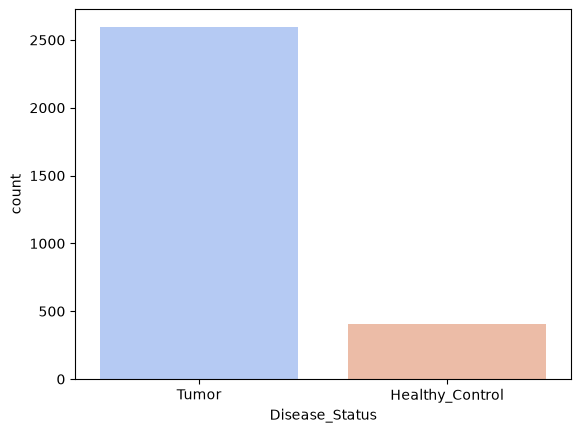

In [10]:
sns.countplot(data=dataset, x="Disease_Status", palette='coolwarm')
plt.show()  

#### b. Inspeksi Distribusi Kelas Fitur

In [11]:
def check_value(cols, top_n=1):
    for col in cols:
        print(dataset[col].value_counts().sort_values(ascending=False).head(top_n))
        print("\n")

check_value(all_feature, top_n=1)

Gene_E_Housekeeping
5.565866    1
Name: count, dtype: int64


Gene_A_Oncogene
4.546474    1
Name: count, dtype: int64


Gene_B_Immune
10.532535    1
Name: count, dtype: int64


Gene_C_Stromal
2.113285    1
Name: count, dtype: int64


Gene_D_Therapy
0.5    20
Name: count, dtype: int64


Pathway_Score_Inflam
1.0    61
Name: count, dtype: int64


UMAP_1
7.818137    1
Name: count, dtype: int64




### *7. Bivariate Analysis*

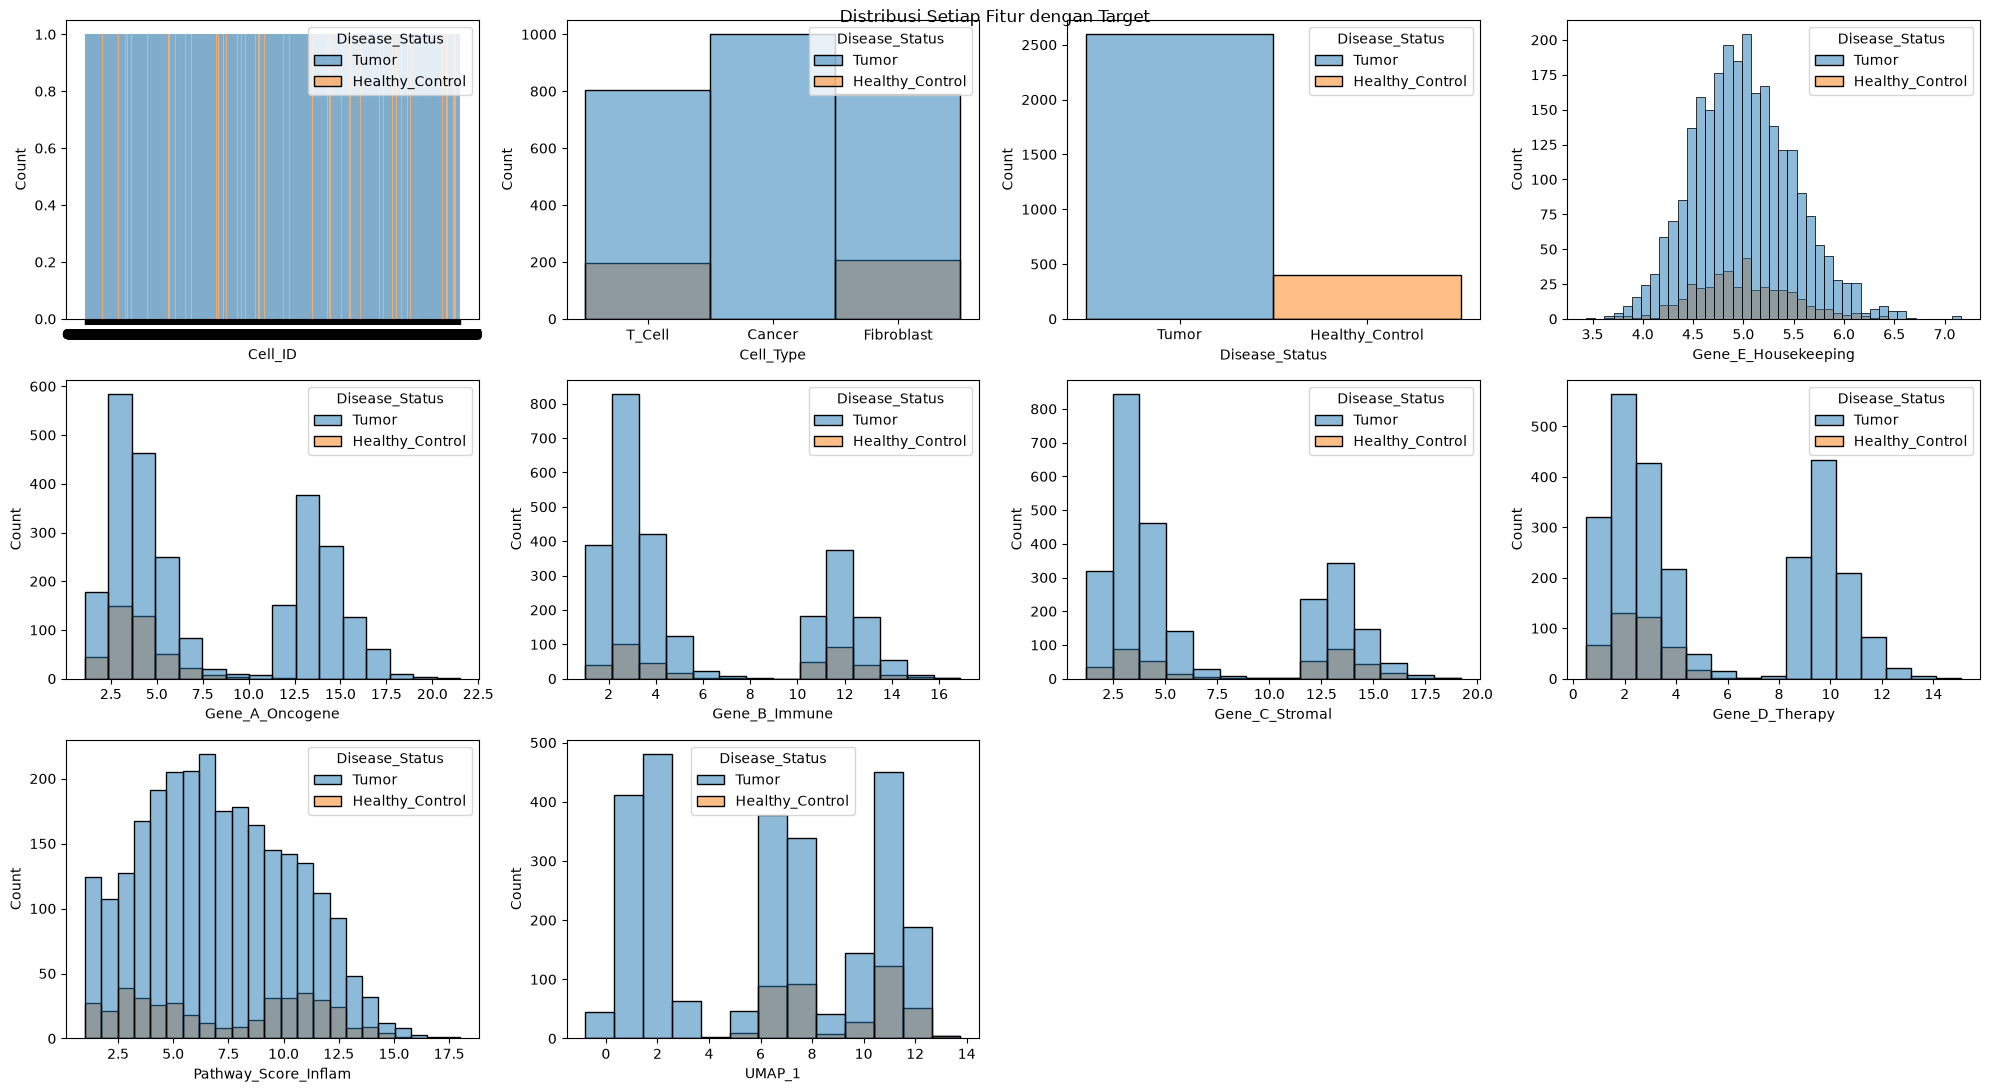

In [12]:
plt.figure(figsize=(20,18))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["Disease_Status"])
plt.suptitle("Distribusi Setiap Fitur dengan Target")
plt.tight_layout()
plt.show()

### *8. Multivariate Analysis*

In [13]:
# sns.pairplot(data=dataset, hue=["Disease_Status"])

### *9. Encoding*

In [14]:
dataset['Cell_Type'].unique()

<StringArray>
['T_Cell', 'Cancer', 'Fibroblast']
Length: 3, dtype: str

In [15]:
dataset['Disease_Status'].unique()

<StringArray>
['Tumor', 'Healthy_Control']
Length: 2, dtype: str

In [16]:
dataset = dataset.drop_duplicates()
map_cell = {"T_Cell" : 0, "Cancer" : 1, "Fibroblast" : 2}
map_target = {"Tumor" : 0, "Healthy_Control" : 1}

dataset['Disease_Status'] = dataset['Disease_Status'].map(map_target)
dataset['Cell_Type'] = dataset['Cell_Type'].map(map_cell)

### *10. Inspeksi Korelasi*

#### a. Mutual Information

In [17]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset[all_feature]
target = dataset['Disease_Status']

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
0,Gene_E_Housekeeping,5.060870
1,Gene_A_Oncogene,5.060870
2,Gene_B_Immune,5.060870
3,Gene_C_Stromal,5.060870
6,UMAP_1,5.060870
4,Gene_D_Therapy,5.046463
5,Pathway_Score_Inflam,5.044060


C:\Users\nizam\AppData\Local\Temp\ipykernel_8700\4128178644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\nizam\AppData\Local\Temp\ipykernel_8700\4128178644.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


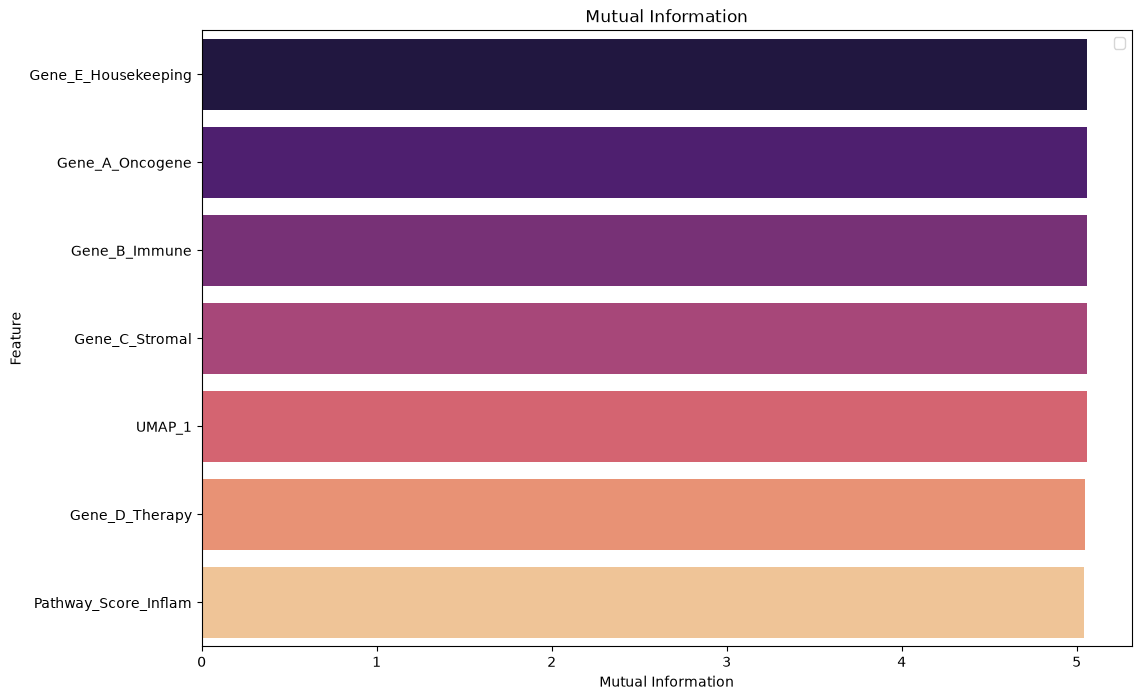

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information")
plt.legend()
plt.show()

#### b. Method Kendall

In [19]:
def kendall_method(x, y):
    concordant = 0
    discordant = 0
    n = len(x)

    for i in range(n - 1):
        for j in range(i+1, n):
            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            if x_diff * y_diff < 0:
                discordant += 1

    if (concordant - discordant) == 0:
        return 0

    return (concordant - discordant) / (concordant + discordant) 

In [20]:
# kendall_all = pd.DataFrame(index=all_feature, columns=all_feature)

# for col1 in all_feature:
#     for col2 in all_feature:
#         kendall_all.loc[col1, col2] = kendall_method(dataset[col1].values, dataset[col2].values)

# kendall_all = kendall_all.astype(float)

# plt.figure(figsize=(9,9))
# sns.heatmap(kendall_all, fmt=".2f", annot=True, cmap="coolwarm")
# plt.show()

#### c. ANOVA

In [21]:
# Pastikan target adalah STRING
target = 'Disease_Status'

# Fungsi ANOVA untuk SATU fitur
def anova_test(dataset, feature_col, target_col):
    # Ambil SATU kolom fitur (jadi Series)
    group0 = dataset[dataset[target_col] == 0][feature_col].dropna()
    group1 = dataset[dataset[target_col] == 1][feature_col].dropna()
    
    n0, n1 = len(group0), len(group1)
    if n0 == 0 or n1 == 0:
        return 0.0

    mean0 = group0.mean()          # scalar
    mean1 = group1.mean()          # scalar
    overall_mean = dataset[feature_col].mean()  # scalar

    ssb = n0 * (mean0 - overall_mean)**2 + n1 * (mean1 - overall_mean)**2
    ssw = ((group0 - mean0)**2).sum() + ((group1 - mean1)**2).sum()

    df_within = n0 + n1 - 2
    if df_within <= 0:
        return 0.0

    msb = ssb / 1          # df_between = 1
    msw = ssw / df_within

    return float(msb / msw) if msw != 0 else 0.0

# HITUNG untuk setiap fitur di num_cols
anova_scores = []
for col in num_cols:  # col = 'Gene_A_Oncogene', dll
    score = anova_test(dataset, col, target)  # ← kirim col (satu string)
    anova_scores.append({"Feature": col, "F_Score": score})

anova_df = pd.DataFrame(anova_scores).sort_values("F_Score", ascending=False)
anova_df

,Feature,F_Score
1,Gene_A_Oncogene,228.121325
6,UMAP_1,219.493926
4,Gene_D_Therapy,213.035591
3,Gene_C_Stromal,75.850056
2,Gene_B_Immune,47.732705
5,Pathway_Score_Inflam,1.404421
0,Gene_E_Housekeeping,0.236784


C:\Users\nizam\AppData\Local\Temp\ipykernel_8700\2310208537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anova_df, x='Feature', y='F_Score', palette = 'magma')


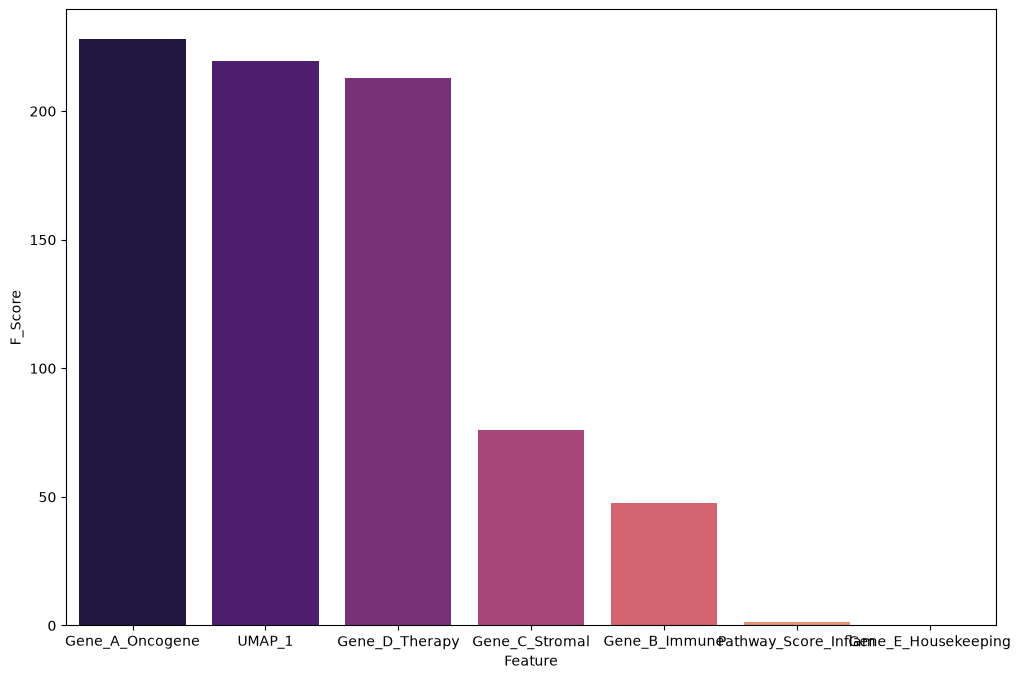

In [22]:
plt.figure(figsize=(12, 8))
sns.barplot(data=anova_df, x='Feature', y='F_Score', palette = 'magma')
plt.show()

### *11. Inspeksi Outlier*

<Axes: xlabel='Disease_Status', ylabel='Gene_E_Housekeeping'>

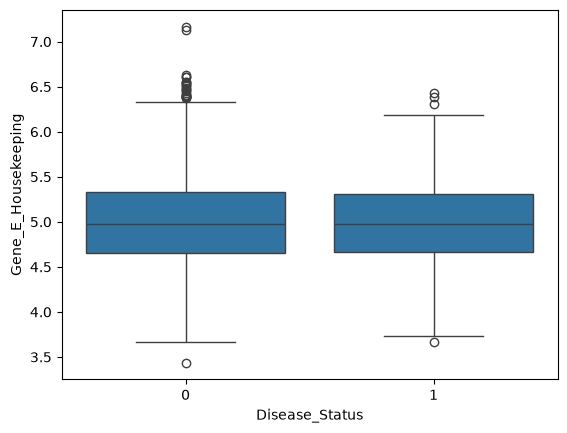

In [23]:
sns.boxplot(data=dataset, x="Disease_Status", y="Gene_E_Housekeeping")

# ***B. Feature Selection***

# ***C. Data Preprocessing***

### 1. Scaling Dataset

In [24]:
means = dataset[num_cols].mean().values
stds = dataset[num_cols].std().values
stds = np.where(stds == 0, 1, stds)

dataset_scaled = dataset.copy()
dataset_scaled[num_cols] = (dataset[num_cols].values - means) / stds

dataset = dataset_scaled

dataset[num_cols].describe()

,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
count,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03
mean,-2.332949e-16,8.052818e-17,1.077656e-16,1.184238e-17,8.052818e-17,-3.155994e-16,1.089499e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.159250e+00,-1.256604e+00,-1.133275e+00,-1.167567e+00,-1.205684e+00,-1.764441e+00,-1.842608e+00
25%,-6.945681e-01,-8.131461e-01,-7.888762e-01,-7.899993e-01,-7.982283e-01,-8.077128e-01,-1.139961e+00
50%,-4.664804e-02,-5.132890e-01,-5.625311e-01,-5.570337e-01,-4.899259e-01,-9.081988e-02,1.243446e-01
75%,6.541695e-01,1.135045e+00,1.206156e+00,1.191601e+00,1.165398e+00,8.036184e-01,1.019080e+00
max,4.363820e+00,2.861389e+00,2.490976e+00,2.539621e+00,2.743488e+00,3.197468e+00,1.823280e+00


#### 2. Data Imbalance

In [25]:
print(dataset['Disease_Status'].value_counts(normalize=True) * 100)

Disease_Status
0    86.5
1    13.5
Name: proportion, dtype: float64


# ***D. Splitting Dataset***

In [26]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "Disease_Status")

# ***E. Data Sampling***

Dataset menunjukkan ketidakseimbangan kelas yang signifikan: 86.5% sampel berasal dari kelas mayoritas dan hanya 13.5% dari kelas minoritas. Mengingat keterbatasan penggunaan library (tidak boleh pakai scikit-learn) dan risiko kehilangan informasi biologis penting dari kelas minoritas, keputusan diambil untuk tidak melakukan teknik sampling (seperti SMOTE atau random undersampling). Sebagai gantinya: 

- Model akan dievaluasi menggunakan metrik yang robust terhadap imbalance: F1-score, precision, recall, dan confusion matrix, bukan akurasi.
- Regularisasi L2 diterapkan untuk mencegah overfitting pada kelas mayoritas.
- Threshold prediksi dapat disesuaikan (opsional) untuk meningkatkan sensitivitas terhadap kelas minoritas.

# ***F. Feature Target Declaration***

In [27]:
X_train = dataset_training[all_feature].to_numpy()
X_test = dataset_testing[all_feature].to_numpy()
y_train = dataset_training["Disease_Status"].to_numpy()
y_test = dataset_testing["Disease_Status"].to_numpy()

# **III. Modeling**

# ***A. Model Application***

In [28]:
class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, lambda_reg=0.1, epochs=1000):
        self.learning_rate = learning_rate
        self.lambda_reg = lambda_reg
        self.epochs = epochs
        self.w = None
        self.b = None
        self.cost_history = []

    def sigmoid(self, z):
        # Clip untuk stabilitas numerik
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def compute_cost(self, X, y):
        m = X.shape[0]
        z = X @ self.w + self.b
        y_pred = self.sigmoid(z)
        epsilon = 1e-10
        # Cross-entropy loss
        loss = -np.mean(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
        # L2 regularization term
        l2_penalty = (self.lambda_reg / (2 * m)) * np.sum(self.w ** 2)
        return loss + l2_penalty

    def fit(self, X, y):
        n_features = X.shape[1]
        # Inisialisasi bobot kecil
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0
        self.cost_history = []

        for epoch in range(self.epochs):
            m = X.shape[0]
            z = X @ self.w + self.b
            y_pred = self.sigmoid(z)

            # Simpan cost tiap epoch
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)

            # Gradien dengan L2 regularization
            dw = (1/m) * (X.T @ (y_pred - y)) + (self.lambda_reg / m) * self.w
            db = (1/m) * np.sum(y_pred - y)

            # Update parameter
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [29]:
model = LogisticRegressionFromScratch(learning_rate=0.01, lambda_reg=0.1, epochs=1000)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

train_0 = np.sum(y_train_pred == 0)
train_1 = np.sum(y_train_pred == 1)
test_0 = np.sum(y_test_pred == 0)
test_1 = np.sum(y_test_pred == 1)

# ***B. Visualisasi Model***

### *1. Distribusi Hasil Prediksi*

#### a. Training Model

([<matplotlib.axis.XTick at 0x2a195bb07d0>,
 [Text(0, 0, 'Tumor'), Text(1, 0, 'Healthy')])

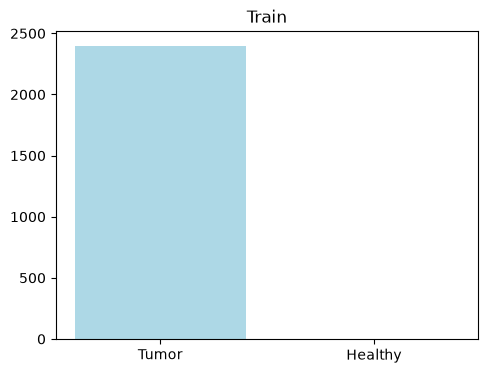

In [30]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.bar([0, 1], [train_0, train_1], color=['lightblue', 'lightcoral'])
plt.title('Train')
plt.xticks([0, 1], ['Tumor', 'Healthy'])

#### b. Testing Model

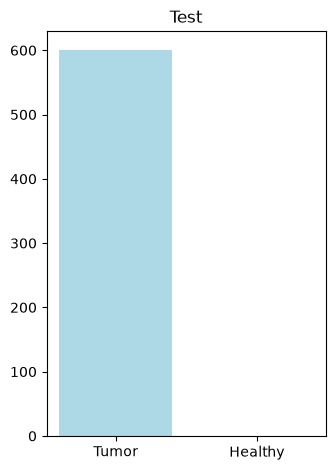

In [31]:
plt.subplot(1, 2, 2)
plt.bar([0, 1], [test_0, test_1], color=['lightblue', 'lightcoral'])
plt.title('Test')
plt.xticks([0, 1], ['Tumor', 'Healthy'])
plt.tight_layout()
plt.show()

### *2. Confusion Matrix*

In [32]:
# ***C. Evaluasi Model***
### *1. Cari Threshold Terbaik Berdasarkan F1-Macro*
from_threshold = 0.1
to_threshold = 0.5
best_f1 = -1
best_thr = 0.5

for thr in np.arange(from_threshold, to_threshold, 0.05):
    y_pred_temp = (y_test_proba >= thr).astype(int)
    _, _, _, f1 = evaluation_metric(y_test, y_pred_temp, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"Threshold terbaik: {best_thr:.2f} → F1-macro: {best_f1:.4f}")

# Gunakan threshold terbaik
y_test_pred_best = (y_test_proba >= best_thr).astype(int)

### *2. Evaluasi Akhir dengan Threshold Terbaik*
acc_train, prec_train, rec_train, f1_train = evaluation_metric(y_train, y_train_pred, average='macro')
acc_test, prec_test, rec_test, f1_test = evaluation_metric(y_test, y_test_pred_best, average='macro')

print(f"\nEVALUASI AKHIR (Threshold = {best_thr:.2f})")
print(f"Train - Acc: {acc_train:.2f}%, Prec: {prec_train:.2f}, Rec: {rec_train:.2f}, F1: {f1_train:.2f}")
print(f"Test  - Acc: {acc_test:.2f}%, Prec: {prec_test:.2f}, Rec: {rec_test:.2f}, F1: {f1_test:.2f}")

### *3. Confusion Matrix Baru*
data_confusion = pd.crosstab(y_test, y_test_pred_best, rownames=['Aktual'], colnames=['Prediksi'])
plt.figure(figsize=(8,6))
sns.heatmap(data_confusion, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_thr:.2f})")
plt.show()

NameError: name 'evaluation_metric' is not defined

### 3. Epoch vs Cost

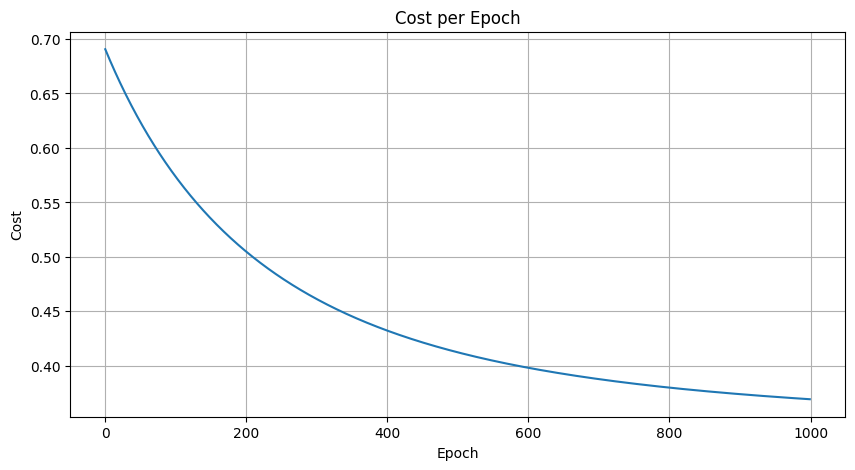

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(model.cost_history)
plt.title("Cost per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

# ***C. Evaluasi Model***

### *1. Confusion Matrix*

In [ ]:
def evaluation_metric(y_true, y_pred, average='macro'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))

    if average == 'macro':
        accs, precs, recs, f1s = [], [], [], []
        for label in labels:
            TP = np.sum((y_true == label) & (y_pred == label))
            FP = np.sum((y_true != label) & (y_pred == label))
            FN = np.sum((y_true == label) & (y_pred != label))
            TN = np.sum((y_true != label) & (y_pred != label))

            acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
            prec = TP / (TP + FP) if (TP + FP) > 0 else 0
            rec = TP / (TP + FN) if (TP + FN) > 0 else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            accs.append(acc)
            precs.append(prec)
            recs.append(rec)
            f1s.append(f1)

        accuracy = np.mean(accs) * 100
        precision = np.mean(precs)
        recall = np.mean(recs)
        f1_score = np.mean(f1s)

    elif average == 'micro':
        total_TP = 0
        total_FP = 0
        total_FN = 0
        for label in labels:
            TP = np.sum((y_true == label) & (y_pred == label))
            FP = np.sum((y_true != label) & (y_pred == label))
            FN = np.sum((y_true == label) & (y_pred != label))
            total_TP += TP
            total_FP += FP
            total_FN += FN

        accuracy = np.mean(y_true == y_pred) * 100
        precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
        recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
        f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    else:
        raise ValueError("average harus 'macro' atau 'micro'")
    
    return accuracy, precision, recall, f1_score

#### a. Training Model

In [ ]:
acc_train, prec_train, rec_train, f1_train = evaluation_metric(y_train, y_train_pred, average='micro')
print(f"Akurasi Train: {acc_train:.2f}%")
print(f"Presisi Train: {prec_train:.2f}")
print(f"Recall Train: {rec_train:.2f}")
print(f"F1 Score Train: {f1_train:.2f}")

Akurasi Train: 86.50%
Presisi Train: 0.86
Recall Train: 0.86
F1 Score Train: 0.86


#### b. Testing Model

In [ ]:
acc_test, prec_test, rec_test, f1_test = evaluation_metric(y_test, y_test_pred, average='micro')
print(f"\nAkurasi Test: {acc_test:.2f}%")
print(f"Presisi Test: {prec_test:.2f}")
print(f"Recall Test: {rec_test:.2f}")
print(f"F1 Score Test: {f1_test:.2f}")


Akurasi Test: 86.50%
Presisi Test: 0.86
Recall Test: 0.86
F1 Score Test: 0.86


### *2. Bias and Variance Model*

C:\Users\USER\AppData\Local\Temp\ipykernel_23920\3468124281.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_eval, x="Metric", y="Value", palette="coolwarm")


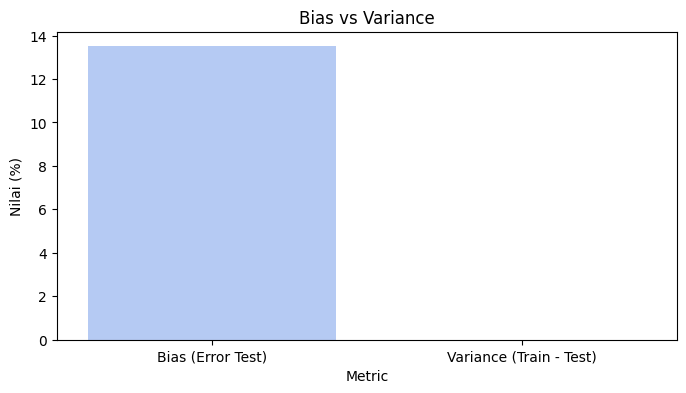

In [ ]:
### *2. Bias and Variance Model*
bias = 100 - acc_test      # ✅ pakai acc_test (sudah didefinisikan di atas)
variance = acc_train - acc_test

data = {
    'Metric': ['Bias (Error Test)', 'Variance (Train - Test)'],
    'Value': [bias, variance]
}
data_eval = pd.DataFrame(data)

plt.figure(figsize=(8,4))
sns.barplot(data=data_eval, x="Metric", y="Value", palette="coolwarm")
plt.title("Bias vs Variance")
plt.ylabel("Nilai (%)")
plt.show()

### *3. K-Fold Cross Validation*

In [ ]:
def stratified_kfold(X, y, k=5, learning_rate=0.01, lambda_reg=0.1, epochs=500):
    # Pastikan y integer
    y = np.array(y)
    X = np.array(X)
    
    # Dapatkan indeks per kelas
    unique_classes = np.unique(y)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    
    # Buat fold kosong
    folds = [[] for _ in range(k)]
    
    # Distribusi stratified
    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_splits = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_splits[i])
    
    accuracies = []
    
    for i in range(k):
        test_idx = np.array(folds[i])
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        
        # Buat model baru tiap fold!
        model_cv = LogisticRegressionFromScratch(
            learning_rate=learning_rate,
            lambda_reg=lambda_reg,
            epochs=epochs
        )
        model_cv.fit(X_train_fold, y_train_fold)
        y_pred_fold = model_cv.predict(X_test_fold)
        
        acc, _, _, _ = evaluation_metric(y_test_fold, y_pred_fold, average="micro")
        accuracies.append(acc)
        print(f"Fold {i+1}: Accuracy = {acc:.2f}%")
    
    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)
    print(f"\nRata-rata Akurasi: {avg_acc:.2f}%")
    print(f"Standar Deviasi: {std_dev:.2f}%")
    
    return avg_acc, std_dev

In [ ]:
X_full = dataset[all_feature].values
y_full = dataset['Disease_Status'].values

avg_acc, std_dev = stratified_kfold(
    X_full, y_full, k=5,
    learning_rate=0.01,
    lambda_reg=0.1,
    epochs=500
)

Fold 1: Accuracy = 86.50%
Fold 2: Accuracy = 86.50%
Fold 3: Accuracy = 86.50%
Fold 4: Accuracy = 86.50%
Fold 5: Accuracy = 86.50%

Rata-rata Akurasi: 86.50%
Standar Deviasi: 0.00%


# **IV. GUI**

In [ ]:
def predict_from_gui():
    try:
        # Ambil input dari entry fields
        inputs = []
        for entry in entry_widgets:
            val = float(entry.get())
            inputs.append(val)
        inputs = np.array(inputs).reshape(1, -1)
        
        # Prediksi probabilitas
        proba = model.predict_proba(inputs)[0]
        pred = "Healthy (Normal)" if proba >= best_thr else "Tumor"
        
        # Tampilkan hasil
        result_label.config(
            text=f"Prediksi: {pred}\nProbabilitas Healthy: {proba:.4f}",
            fg="green" if pred == "Healthy (Normal)" else "red"
        )
    except Exception as e:
        result_label.config(text=f"Error: {str(e)}", fg="black")

# Buat window utama
root = tkinter.Tk()
root.title("Cancer Microenvironment Predictor")
root.geometry("600x500")

# Judul
title_label = tkinter.Label(root, text="Prediksi Kondisi Sel T", font=("Arial", 16, "bold"))
title_label.pack(pady=10)

# Frame untuk input
input_frame = tkinter.Frame(root)
input_frame.pack(pady=10)

entry_widgets = []
for i, feature in enumerate(all_feature):
    row = tkinter.Frame(input_frame)
    label = tkinter.Label(row, width=25, text=feature.replace('_', ' ') + ":", anchor='w')
    entry = tkinter.Entry(row)
    entry.insert(0, "0.0")  # default value
    row.pack(side=tkinter.TOP, fill=tkinter.X, padx=5, pady=2)
    label.pack(side=tkinter.LEFT)
    entry.pack(side=tkinter.RIGHT, expand=tkinter.YES, fill=tkinter.X)
    entry_widgets.append(entry)

# Tombol prediksi
predict_button = tkinter.Button(root, text="Prediksi", command=predict_from_gui, bg="lightblue")
predict_button.pack(pady=15)

# Label hasil
result_label = tkinter.Label(root, text="Masukkan nilai fitur lalu klik Prediksi", 
                             font=("Arial", 12), justify=tkinter.LEFT, wraplength=500)
result_label.pack(pady=10)

# Info threshold
info_label = tkinter.Label(root, text=f"Threshold optimal: {best_thr:.2f} | Kelas: 0=Tumor, 1=Healthy",
                           font=("Arial", 9), fg="gray")
info_label.pack(side=tkinter.BOTTOM, pady=5)

# Jalankan GUI
root.mainloop()